In [1]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import os

print(os.listdir('/content/drive/MyDrive/Colab Notebooks/Dataset'))

['cat_v_dog-dataset.zip']


In [3]:
# extract data from zip file
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Dataset/cat_v_dog-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall("/content")

In [4]:
# import dependencies and transform into dataset and data loaders
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    "/content/dataset/training_set",
    transform=transform
)
val_dataset = datasets.ImageFolder(
    "/content/dataset/test_set/",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [5]:
train_dataset.classes

['cats', 'dogs']

In [6]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 256, 256])
torch.Size([32])


In [7]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Sequential(

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = self.fc(x)

        return x

In [8]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
print(device)

cuda


In [9]:
!pip install torchinfo

In [10]:
from torchinfo import summary

summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [32, 1]                   --
├─Sequential: 1-1                        [32, 256, 12, 12]         --
│    └─Conv2d: 2-1                       [32, 32, 222, 222]        896
│    └─BatchNorm2d: 2-2                  [32, 32, 222, 222]        64
│    └─ReLU: 2-3                         [32, 32, 222, 222]        --
│    └─MaxPool2d: 2-4                    [32, 32, 111, 111]        --
│    └─Conv2d: 2-5                       [32, 64, 109, 109]        18,496
│    └─BatchNorm2d: 2-6                  [32, 64, 109, 109]        128
│    └─ReLU: 2-7                         [32, 64, 109, 109]        --
│    └─MaxPool2d: 2-8                    [32, 64, 54, 54]          --
│    └─Conv2d: 2-9                       [32, 128, 52, 52]         73,856
│    └─BatchNorm2d: 2-10                 [32, 128, 52, 52]         256
│    └─ReLU: 2-11                        [32, 128, 52, 52]         --
│   

In [11]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
print(train_dataset.classes)

print(len(train_dataset.classes))

['cats', 'dogs']
2


In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])
print(labels.dtype)
print(images.dtype)
print(labels.unique())

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([0, 1, 0, 0, 0, 0, 0, 1, 0, 0])
torch.int64
torch.float32
tensor([0, 1])


In [14]:
num_epochs = 10
train_accuracies = []
train_losses = []
val_accuracies = []
val_losses = []
all_predictions = []
all_labels = []

for epoch in range(num_epochs):
    # ---------------- TRAINING ----------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.float().view(-1,1).to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()
        running_loss += loss.item() * images.size(0)

        # Predictions
        predictions = torch.sigmoid(outputs)
        predicted = (predictions > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = 100 * correct / total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(train_accuracy)

    # ---------------- VALIDATION ----------------
    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().view(-1,1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            predictions = torch.sigmoid(outputs)
            predicted = (predictions > 0.5).float()

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(val_accuracy)
    print(f"""
Epoch [{epoch+1}/{num_epochs}]

Train Loss: {epoch_train_loss:.4f}
Train Accuracy: {train_accuracy:.2f}%

Validation Loss: {epoch_val_loss:.4f}
Validation Accuracy: {val_accuracy:.2f}%
""")


Epoch [1/10]

Train Loss: 0.6335
Train Accuracy: 63.52%

Validation Loss: 0.6924
Validation Accuracy: 62.85%


Epoch [2/10]

Train Loss: 0.5762
Train Accuracy: 70.26%

Validation Loss: 0.8981
Validation Accuracy: 55.10%


Epoch [3/10]

Train Loss: 0.5445
Train Accuracy: 73.16%

Validation Loss: 0.5486
Validation Accuracy: 71.70%


Epoch [4/10]

Train Loss: 0.5199
Train Accuracy: 74.26%

Validation Loss: 0.7050
Validation Accuracy: 57.80%


Epoch [5/10]

Train Loss: 0.5065
Train Accuracy: 75.70%

Validation Loss: 0.5616
Validation Accuracy: 70.95%


Epoch [6/10]

Train Loss: 0.4907
Train Accuracy: 76.51%

Validation Loss: 0.5587
Validation Accuracy: 70.55%


Epoch [7/10]

Train Loss: 0.4709
Train Accuracy: 77.88%

Validation Loss: 0.5711
Validation Accuracy: 71.80%


Epoch [8/10]

Train Loss: 0.4524
Train Accuracy: 79.22%

Validation Loss: 0.5167
Validation Accuracy: 75.50%


Epoch [9/10]

Train Loss: 0.4388
Train Accuracy: 79.84%

Validation Loss: 0.4535
Validation Accuracy: 78.15%




In [15]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        all_predictions.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.numpy()
        )

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report (
    all_labels,
    all_predictions,
    target_names=['Cat','Dog']
))

              precision    recall  f1-score   support

         Cat       0.84      0.79      0.82      1000
         Dog       0.80      0.85      0.83      1000

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



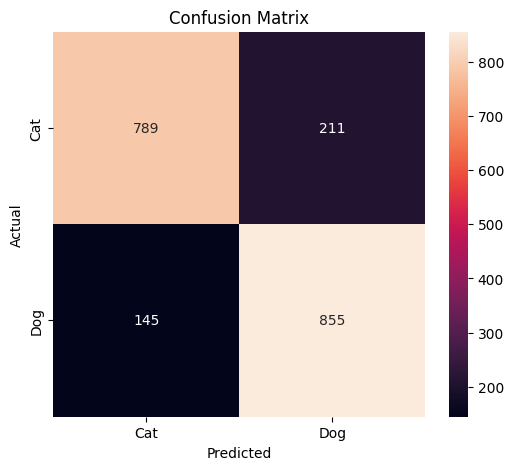

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Cat','Dog'],
    yticklabels=['Cat','Dog']
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

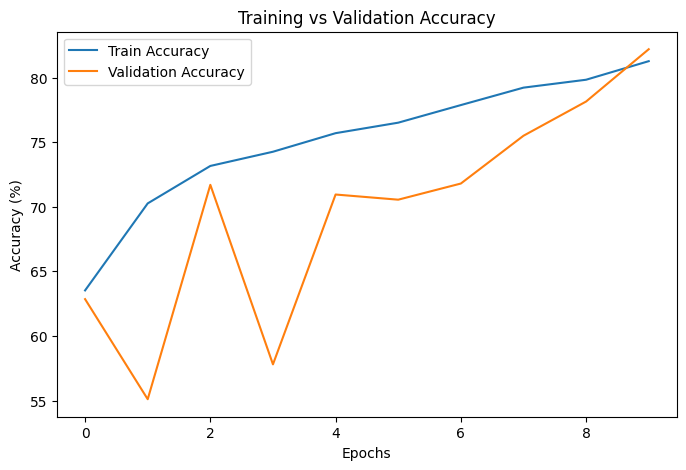

In [18]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

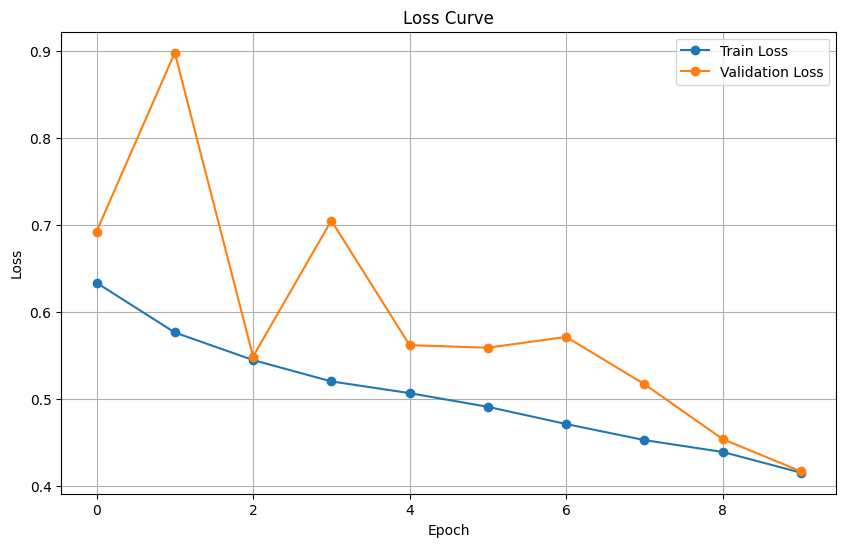

In [19]:
plt.figure(figsize=(10,6))

plt.plot(
    train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
train_losses

[0.6334565912485123,
 0.5762175945043564,
 0.5445097881555557,
 0.5199391742944718,
 0.5064523754119873,
 0.49068147790431976,
 0.4708880058526993,
 0.45241001731157304,
 0.43875952178239824,
 0.4148781325817108]